Install requirements

In [ ]:
import sys
!{sys.executable} -m pip install -r requirements.txt


Imports and parameters

In [1]:
import mediacloud.api as mcapi
from importlib.metadata import version
import datetime as dt
import pandas as pd
from IPython.display import JSON
import bokeh.io
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.colors as mcolors
from matplotlib import gridspec
import matplotlib.lines as mlines
from matplotlib.ticker import MaxNLocator

bokeh.io.reset_output()
bokeh.io.output_notebook()

Loading BokehJS ...

In [2]:
# Set your personal API KEY
MC_API_KEY = 'b32652584a00c2bc643b93fe210c9ade8fd6df80'
mc = mcapi.SearchApi(MC_API_KEY)
f'Using Media Cloud python client v{version("mediacloud")}'

# Load data
OUTPUT_PATH = Path(r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\Mediacloud_download+basic_graphs")
CSV_PATH  = r"C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Datasets"
ENCODING = "cp1252"
START = dt.date(2010, 1, 1)
END = dt.date(2025, 12, 31)

df = pd.read_csv(Path(CSV_PATH) / "Google_dataset.csv", encoding=ENCODING)
df.columns = df.columns.str.strip()
print(df.head())

SUBTYPE_COLOURS: dict[str, str] = {
    "Aedes":       "#E69F00",
    "Chikungunya": "#56B4E9",
    "Dengue":      "#009E73",
    "Zika":        "#F0E442",
    "Culex":       "#0072B2",
    "Usutu":       "#D55E00",
    "West Nile":   "#CC79A7",
}

COUNTRY_COLOURS: dict[str, str] = {
    "Germany":       "#E69F00",
    "Austria":       "#56B4E9",
    "Switzerland":       "#009E73",
    "France":       "#0072B2",
    "Spain":       "#F0E442",
    "Italy":       "#CC79A7",
}

SYSTEM_COLOURS: dict[str, str] = {
    "Aedes-borne disease system": "#0072B2",
    "Culex-borne disease system": "#D55E00",
}

SYSTEM_STYLES: dict[str, str] = {
    "Aedes-borne disease system": "dashed",
    "Culex-borne disease system": "solid",
}

COUNTRY_LABELS: dict[str, str] = {
    "DE": ["Germany"],
    "AT": ["Austria"],
    "CH": ["Switzerland"],
    "IT": ["Italy"],
    "ES": ["Spain"],
    "FR": ["France"],
}

COUNTRY_LANGUAGES: dict[str, list[str]] = {
    "DE": ["German"],
    "AT": ["German"],
    "CH": ["German", "French", "Italian"],
    "IT": ["Italian"],
    "ES": ["Spanish"],
    "FR": ["French"],
}

# Preferred country order in the figure
COUNTRY_ORDER = ["Germany", "Austria", "Switzerland", "Italy", "Spain", "France"]

ANCHOR_PER_COUNTRY: dict[str, str] = {
    "Germany": "Mücke",
    "Austria": "Mücke",
    "Switzerland": "Mücke",
    "Italy": "Zanzara",
    "Spain": "Mosquito",
    "France": "Moustique",
}

                Keyword                      System Sub-type     Type Language
0      Aedes albopictus  Aedes-borne disease system    Aedes   Animal    Latin
1        Aedes mosquito  Aedes-borne disease system    Aedes   Animal  English
2  Asian tiger mosquito  Aedes-borne disease system    Aedes   Animal  English
3        Tiger mosquito  Aedes-borne disease system    Aedes   Animal  English
4                  Zika  Aedes-borne disease system     Zika  Disease      All


## Media attention

Uses national and regional/local collections from media cloud for each country. Done per sub-type and system.

In [3]:
# Sub-type lists per country
country_subtype_kws = {}

for geo, languages in COUNTRY_LANGUAGES.items():

    country_name = COUNTRY_LABELS[geo][0]

    country_df = df[df["Language"].isin(languages)]

    country_subtype_kws[country_name] = {}

    for subtype, group in country_df.groupby("Sub-type"):

        kws = group["Keyword"].tolist()

        universal = df.loc[
            (df["Language"].isin(["All", "Latin"])) &
            (df["Sub-type"] == subtype),
            "Keyword"
        ].tolist()

        country_subtype_kws[country_name][subtype] = list(
            dict.fromkeys(kws + universal)
        )

print(country_subtype_kws)

# System lists per country
country_systems_kws = {}

for geo, languages in COUNTRY_LANGUAGES.items():

    country_name = COUNTRY_LABELS[geo][0]

    country_df = df[df["Language"].isin(languages)]

    country_systems_kws[country_name] = {}

    for system, group in country_df.groupby("System"):

        kws = group["Keyword"].tolist()

        universal = df.loc[
            (df["Language"].isin(["All", "Latin"])) &
            (df["System"] == system),
            "Keyword"
        ].tolist()

        country_systems_kws[country_name][system] = list(
            dict.fromkeys(kws + universal)
        )

print(country_systems_kws)

{'Germany': {'Aedes': ['Aedes-Mücke', 'Aedes Mücke', 'Tigermücke', 'Tiger Mücke', 'Asiatische Tigermücke', 'Aedes albopictus'], 'Chikungunya': ['Chikungunyafieber', 'Chikungunya Fieber', 'Chikungunya-Virus', 'Chikungunya Virus', 'Chikungunya'], 'Culex': ['Gemeine Stechmücke', 'Nördliche Hausmücke', 'Hausmücke', 'Culex-Mücke', 'Culex pipiens', 'Culex torrentium', 'Culex modestus'], 'Dengue': ['Denguefieber', 'Dengue-Fieber', 'Dengue Fieber', 'Knochenbrecherfieber', 'Siebentagefieber', 'Dengue'], 'Usutu': ['Usutu-Virus', 'Usutu Virus'], 'West Nile': ['West-Nil-Virus', 'West Nil Virus', 'West-Nil-Fieber', 'West Nil Fieber'], 'Zika': ['Zika Virus', 'Zikavirus', 'Zika-Virus', 'Zika-Fieber', 'Zika Fieber', 'Zika']}, 'Austria': {'Aedes': ['Aedes-Mücke', 'Aedes Mücke', 'Tigermücke', 'Tiger Mücke', 'Asiatische Tigermücke', 'Aedes albopictus'], 'Chikungunya': ['Chikungunyafieber', 'Chikungunya Fieber', 'Chikungunya-Virus', 'Chikungunya Virus', 'Chikungunya'], 'Culex': ['Gemeine Stechmücke', 'Nör

In [4]:
# Restructure dictionary into Solr query strings
def build_mc_query(keywords):
    kw_part = " OR ".join([f'"{k}"' for k in keywords])
    query = f"({kw_part})"
    return query

subtype_queries_temp = {}

for country, subtypes in country_subtype_kws.items():
    for subtype, keywords in subtypes.items():
        subtype_queries_temp[(country, subtype)] = build_mc_query(keywords)

system_queries_temp = {}

for country, systems in country_systems_kws.items():
    for system, keywords in systems.items():
        system_queries_temp[(country, system)] = build_mc_query(keywords)

# Define country filters
country_filters = {
    "Germany": {
        "start_date": START,
        "end_date": END,
        "collection_ids": [34412409, 38379816],
    },
    "Austria": {
        "start_date": START,
        "end_date": END,
        "collection_ids": [34412245, 38378035],
    },
    "Switzerland": {
        "start_date": START,
        "end_date": END,
        "collection_ids": [34411591, 38380954],
    },
    "Italy": {
        "start_date": START,
        "end_date": END,
        "collection_ids": [34412372, 38380117],
    },
    "Spain": {
        "start_date": START,
        "end_date": END,
        "collection_ids": [34412356, 38002034],
    },
    "France": {
        "start_date": START,
        "end_date": END,
        "collection_ids": [34412146, 38379799],
    },
}

In [ ]:
# Run subtype level queries
subtype_queries = {}

for (country, subtype), query in subtype_queries_temp.items():

    filters = country_filters[country]

    subtype_queries[(country, subtype)] = mc.story_count_over_time(
        query=query,
        **filters
    )

# Run system level queries
system_queries = {}

for (country, system), query in system_queries_temp.items():

    filters = country_filters[country]

    system_queries[(country, system)] = mc.story_count_over_time(
        query=query,
        **filters
    )

#Run separate call for anchor words
anchor_queries = {}

for country, query in ANCHOR_PER_COUNTRY.items():

    filters = country_filters[country]

    anchor_queries[country] = mc.story_count_over_time(
        query=query,
        **filters
    )

# Convert output to dataframe
subtype_dfs = {}

for (country, system), records in subtype_queries.items():
    df = pd.DataFrame(records)
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")

    subtype_dfs[(country, system)] = df

subtype_df = pd.concat(subtype_dfs, axis=1)

system_dfs = {}

for (country, system), records in system_queries.items():
    df = pd.DataFrame(records)
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")

    system_dfs[(country, system)] = df

system_df = pd.concat(system_dfs, axis=1)

anchor_dfs = {}

for country, records in anchor_queries.items():
    df = pd.DataFrame(records)
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")

    anchor_dfs[country] = df

anchor_df = pd.concat(anchor_dfs, axis=1)

# Save query output
means_path = OUTPUT_PATH / "subtype_queries_daily.csv"
subtype_df.to_csv(means_path, encoding=ENCODING)
print(f"Saved → {means_path}")
print(subtype_df.head())

means_path = OUTPUT_PATH / "system_queries_daily.csv"
system_df.to_csv(means_path, encoding=ENCODING)
print(f"Saved → {means_path}")
print(system_df.head())

means_path = OUTPUT_PATH / "anchor_queries_daily.csv"
anchor_df.to_csv(means_path, encoding=ENCODING)
print(f"Saved → {means_path}")
print(anchor_df.head())

Get subtypes monthly as that is the graph we decided to use. Can equally be done for system and anchor.

In [55]:
# Convert to monthly
subtype_df.index = pd.to_datetime(subtype_df.index)

# Aggregate only count variables
monthly = subtype_df.resample("MS").sum()

# Recompute all ratio columns
for country, subtype, metric in monthly.columns:
    if metric == "ratio":
        monthly[(country, subtype, "ratio")] = (
            monthly[(country, subtype, "count")]
            / monthly[(country, subtype, "total_count")] * 100
        )

means_path = OUTPUT_PATH / "subtype_queries_monthly.csv"
monthly.to_csv(means_path, encoding=ENCODING)
print(f"Saved → {means_path}")
print(monthly.head())

Saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\subtype_queries_monthly.csv
               Germany                                                        \
                 Aedes             Chikungunya                   Culex         
           total_count count ratio total_count count ratio total_count count   
date                                                                           
2010-01-01         631     0   0.0         631     0   0.0         631     0   
2010-02-01         624     0   0.0         624     0   0.0         624     0   
2010-03-01         615     0   0.0         615     0   0.0         615     0   
2010-04-01         959     0   0.0         959     0   0.0         959     0   
2010-05-01        1415     0   0.0        1415     0   0.0        1415     0   

                              ...    France                          \
                      Dengue  ...    Dengue       Usutu               
     

C:\Users\annab\AppData\Local\Temp\ipykernel_11316\2176556990.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  monthly[(country, subtype, "ratio")] = (


In [21]:
# Convert to monthly
anchor_df.index = pd.to_datetime(anchor_df.index)

# Aggregate only count variables
monthly = anchor_df.resample("MS").sum()

# Recompute all ratio columns
for country, metric in monthly.columns:
    if metric == "ratio":
        monthly[(country, "ratio")] = (
            monthly[(country, "count")]
            / monthly[(country, "total_count")] * 100
        )

means_path = OUTPUT_PATH / "anchor_queries_monthly.csv"
monthly.to_csv(means_path, encoding=ENCODING)
print(f"Saved → {means_path}")
print(monthly.head())

Saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\anchor_queries_monthly.csv
               Germany                     Austria             Switzerland  \
           total_count count     ratio total_count count ratio total_count   
date                                                                         
2010-01-01         631     1  0.158479        74.0   0.0   0.0        64.0   
2010-02-01         624     0  0.000000        62.0   0.0   0.0        16.0   
2010-03-01         615     0  0.000000        74.0   0.0   0.0        27.0   
2010-04-01         959     0  0.000000        80.0   0.0   0.0        26.0   
2010-05-01        1415     0  0.000000        39.0   0.0   0.0        73.0   

                             Italy                   Spain                  \
           count ratio total_count count ratio total_count count     ratio   
date                                                                         
2010-01-01

C:\Users\annab\AppData\Local\Temp\ipykernel_53836\4072330858.py:10: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  monthly[(country, "ratio")] = (


## Media framing

Get word counts.

In [ ]:
# Run subtype level queries
subtype_queries = {}

for (country, subtype), query in subtype_queries_temp.items():

    filters = country_filters[country]

    subtype_queries[(country, subtype)] = mc.words(
        query=query,
        **filters
    )

# Run system level queries
system_queries = {}

for (country, system), query in system_queries_temp.items():

    filters = country_filters[country]

    system_queries[(country, system)] = mc.words(
        query=query,
        **filters
    )

#Run separate call for anchor words
anchor_queries = {}

for country, query in ANCHOR_PER_COUNTRY.items():

    filters = country_filters[country]

    anchor_queries[country] = mc.words(
        query=query,
        **filters
    )

# Convert output to dataframe
subtype_dfs = {}

for (country, system), records in subtype_queries.items():
    subtype_dfs[(country, system)] = pd.DataFrame(records)

subtype_df2 = pd.concat(subtype_dfs, axis=1)

system_dfs = {}

for (country, system), records in system_queries.items():
    system_dfs[(country, system)] = pd.DataFrame(records)

system_df2 = pd.concat(system_dfs, axis=1)

anchor_dfs = {}

for country, records in anchor_queries.items():
    anchor_dfs[country] = pd.DataFrame(records)

anchor_df2 = pd.concat(anchor_dfs, axis=1)

# Save query output
means_path = OUTPUT_PATH / "anchor_queries_words.csv"
anchor_df2.to_csv(means_path, encoding=ENCODING)
print(f"Saved → {means_path}")
print(anchor_df2.head())

means_path = OUTPUT_PATH / "subtype_queries_words.csv"
subtype_df2.to_csv(means_path, encoding=ENCODING)
print(f"Saved → {means_path}")
print(subtype_df2.head())

means_path = OUTPUT_PATH / "system_queries_words.csv"
system_df2.to_csv(means_path, encoding=ENCODING)
print(f"Saved → {means_path}")
print(system_df2.head())

## Plots

In [5]:
subtype_df = pd.read_csv("subtype_queries_monthly.csv", encoding=ENCODING, header=[0, 1, 2], index_col=0)
system_df = pd.read_csv("system_queries_daily.csv", encoding=ENCODING, header=[0, 1, 2], index_col=0,)
anchor_df = pd.read_csv("anchor_queries_monthly.csv", encoding=ENCODING, header=[0, 1], index_col=0,)
anchor_df.index = pd.to_datetime(anchor_df.index, errors="coerce")

def convert_ratio_to_percent(df):
    df = df.copy()

    ratio_cols = [col for col in df.columns if col[2] == "ratio"]

    df.loc[:, ratio_cols] = df.loc[:, ratio_cols] * 100

    return df


subtype_df = convert_ratio_to_percent(subtype_df)

def convert_ratio_to_percent_multi2(df):
    df = df.copy()

    ratio_cols = [col for col in df.columns if col[1] == "ratio"]

    df.loc[:, ratio_cols] = df.loc[:, ratio_cols] * 100

    return df


anchor_df = convert_ratio_to_percent_multi2(anchor_df)

In [6]:
def prep_ecdc(df):
    df = df.copy()

    df.columns = df.columns.str.lower().str.strip()

    # --- FORCE SAFE NUMERIC CONVERSION FIRST ---
    num = pd.to_numeric(df["numvalue"].astype(str), errors="coerce")
    df["numvalue"] = num.fillna(0).astype(float)

    # --- DATE ---
    df["date"] = pd.to_datetime(df["time"], format="%Y-%m")

    # --- CLEAN NAMES ---
    df = df.rename(columns={
        "regionname": "country",
        "numvalue": "cases"
    })

    return df[["country", "date", "cases"]]

dengue = prep_ecdc(pd.read_csv(Path(CSV_PATH) / "ECDC_surveillance_data_Dengue.csv"))
chik   = prep_ecdc(pd.read_csv(Path(CSV_PATH) / "ECDC_surveillance_data_Chikungunya_virus_disease.csv"))
wnv    = prep_ecdc(pd.read_csv(Path(CSV_PATH) / "ECDC_surveillance_data_West_Nile_virus_infection.csv"))
zika   = prep_ecdc(pd.read_csv(Path(CSV_PATH) / "ECDC_surveillance_data_Zika_virus_infection.csv"))

disease_lookup = {
    "Dengue": dengue,
    "Chikungunya": chik,
    "West Nile": wnv,
    "Zika": zika,
}

In [7]:
def _loess(x, y, frac=0.5, eps=1e-6):
    """
    Simple local regression smoother (LOESS-like),
    hardened for pandas / mixed dtype inputs.
    """

    # ------------------------------------------------------------
    # HARD SAFETY: force clean 1D numeric arrays
    # ------------------------------------------------------------
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)

    n = len(x)
    out = np.full(n, np.nan, dtype=float)

    # not enough data
    finite = np.isfinite(y)
    if finite.sum() < 3:
        return out

    half_window = max(int(np.ceil(frac * n / 2)), 2)

    for i in range(n):

        lo = max(0, i - half_window)
        hi = min(n, i + half_window)

        xi = x[lo:hi].astype(float).reshape(-1)
        yi = y[lo:hi].astype(float).reshape(-1)

        mask = np.isfinite(yi).reshape(-1)

        if mask.sum() < 2:
            continue

        xi = xi[mask]
        yi = yi[mask]

        # log transform (stabilises positivity)
        log_y = np.log(np.maximum(yi, 0) + eps)

        # --------------------------------------------------------
        # distance + tricube weights
        # --------------------------------------------------------
        d = np.abs(xi - float(x[i]))
        max_d = np.max(d) if np.max(d) > 0 else 1.0

        w = (1 - (d / max_d) ** 3) ** 3
        w = np.asarray(w, dtype=float)

        # design matrix (linear fit locally)
        A = np.column_stack([np.ones_like(xi), xi])

        Aw = A * w[:, None]
        yw = log_y * w

        try:
            coef = np.linalg.lstsq(Aw, yw, rcond=None)[0]
            pred_log = coef[0] + coef[1] * x[i]
            out[i] = np.exp(pred_log)
        except np.linalg.LinAlgError:
            continue

    return out

## MAIN - Monthly and yearly

In [9]:
def plot_country_averages(
    subtype_df,
    anchor_series,
    disease_lookup,
    save_dir,
    freq="month",
):

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    df = subtype_df.copy()
    df.index = pd.to_datetime(df.index)

    # ------------------------------------------------------------
    # infer structure from MultiIndex columns
    # ------------------------------------------------------------
    countries = [
        c for c in COUNTRY_ORDER
        if c in {col[0] for col in df.columns}
    ]

    subtypes = sorted({
        col[1] for col in df.columns
        if col[0] in countries and col[2] == "ratio"
    })

    plot_items = subtypes + ["__anchor__"]

    # ------------------------------------------------------------
    # offsets (same logic as original)
    # ------------------------------------------------------------
    if freq == "month":
        width = 0.08
        offsets = np.linspace(-0.25, 0.25, len(countries))
    else:
        width = 0.10
        offsets = np.linspace(-0.30, 0.30, len(countries))

    # ============================================================
    # MAIN LOOP
    # ============================================================
    for item in plot_items:

        is_disease = item in disease_lookup
        case_options = [False, True] if is_disease else [False]

        for show_cases in case_options:

            fig, ax = plt.subplots(figsize=(10, 5))

            if show_cases:
                ax2 = ax.twinx()
                ax.set_zorder(2)
                ax2.set_zorder(1)
                ax.patch.set_alpha(0)

            # ----------------------------------------------------
            # SEARCH / MEAN SERIES
            # ----------------------------------------------------
            for offset, country in zip(offsets, countries):

                if item == "__anchor__":

                    if country not in anchor_series:
                        continue

                    series = anchor_series[country, "ratio"].copy()

                else:

                    series = df[(country, item, "ratio")]

                series = series.sort_index()

                # ---------------- MONTH ----------------
                if freq == "month":

                    monthly = (
                        series.groupby(series.index.month)
                        .mean()
                        .reindex(range(1, 13))
                    )

                    x = np.arange(12)

                    y = monthly.to_numpy(dtype=float)

                    mask = np.isfinite(y)
                    if mask.sum() < 3:
                        smooth = np.full_like(y, np.nan, dtype=float)
                    else:
                        smooth = _loess(x, y, frac=0.5)

                    ax.plot(
                        np.arange(1, 13),
                        smooth,
                        linewidth=2.5,
                        color=COUNTRY_COLOURS[country],
                        label=COUNTRY_LABELS.get(country, country),
                    )

                # ---------------- YEAR ----------------
                else:

                    yearly = series.groupby(series.index.year).mean()

                    x = np.arange(len(yearly))

                    smooth = _loess(x, yearly.values, frac=0.4)

                    ax.plot(
                        yearly.index,
                        smooth,
                        linewidth=2.5,
                        color=COUNTRY_COLOURS[country],
                        label=COUNTRY_LABELS.get(country, country),
                        zorder=3,
                    )

                # ------------------------------------------------
                # CASE OVERLAY (only if enabled + disease exists)
                # ------------------------------------------------
                if (not show_cases) or (item not in disease_lookup):
                    continue

                ddf = disease_lookup[item]

                dsub = ddf[ddf["country"] == country].copy()
                if dsub.empty:
                    continue

                dsub = dsub.sort_values("date")
                dsub = dsub[dsub["cases"] > 0]

                if dsub.empty:
                    continue

                first = dsub.iloc[0]
                maximum = dsub.loc[dsub["cases"].idxmax()]

                events = [first]
                if first.name != maximum.name:
                    events.append(maximum)

                for event in events:

                    if freq == "month":
                        xpos = event["date"].month + offset
                    else:
                        xpos = event["date"].year + offset

                    ax2.bar(
                        xpos,
                        event["cases"],
                        width=width,
                        color=COUNTRY_COLOURS[country],
                        alpha=0.6,
                        zorder=1,
                    )

            # ====================================================
            # FORMATTING
            # ====================================================
            if freq == "month":
                ax.set_xticks(range(1, 13, 2))
                ax.set_xticklabels(
                    ["Jan", "Mar", "May", "Jul", "Sep", "Nov"],
                    fontsize=15,
                )
            else:
                ax.set_xticks(range(2010, 2026, 2))
                if show_cases:
                    ax2.set_xlim(2010, 2025)

            ax.set_ylim(bottom=0)
            ax.grid(axis="y", alpha=0.3)

            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.tick_params(labelsize=14)

            ax.set_ylabel(
                "Mean percentage of documents with keyword",
                fontsize=14,
            )

            ax.set_xlabel("Month" if freq == "month" else "Year", fontsize=15)

            title = "Mosquito" if item == "__anchor__" else item

            ax.set_title(title, fontsize=22, fontweight="bold")

            if show_cases:
                ax2.set_ylabel("Cases", fontsize=15)
                ax2.tick_params(labelsize=14)
                ax2.spines["top"].set_visible(False)
                ax2.yaxis.set_major_locator(MaxNLocator(integer=True))
                ax2.margins(x=0)

            ax.margins(x=0)

            if freq == "month":
                ax.legend(
                    title="Country",
                    fontsize=13,
                    title_fontsize=15,
                    bbox_to_anchor=(1.18, 1),
                    loc="upper left",
                    frameon=True,
                )

            plt.tight_layout()

            suffix = "_with_cases" if show_cases else "_no_cases"

            outfile = (
                save_dir /
                f"{title.replace(' ', '_')}_{freq}_average{suffix}.pdf"
            )

            fig.savefig(outfile, dpi=300, bbox_inches="tight")
            plt.close(fig)

plot_country_averages(
     subtype_df, 
     anchor_df, 
     disease_lookup, OUTPUT_PATH / "Figures_monthly_country_means", 
     freq="month", ) 

plot_country_averages( 
    subtype_df, 
    anchor_df, 
    disease_lookup, OUTPUT_PATH / "Figures_yearly_country_means", 
    freq="year", )

## APPENDIX - Yearly

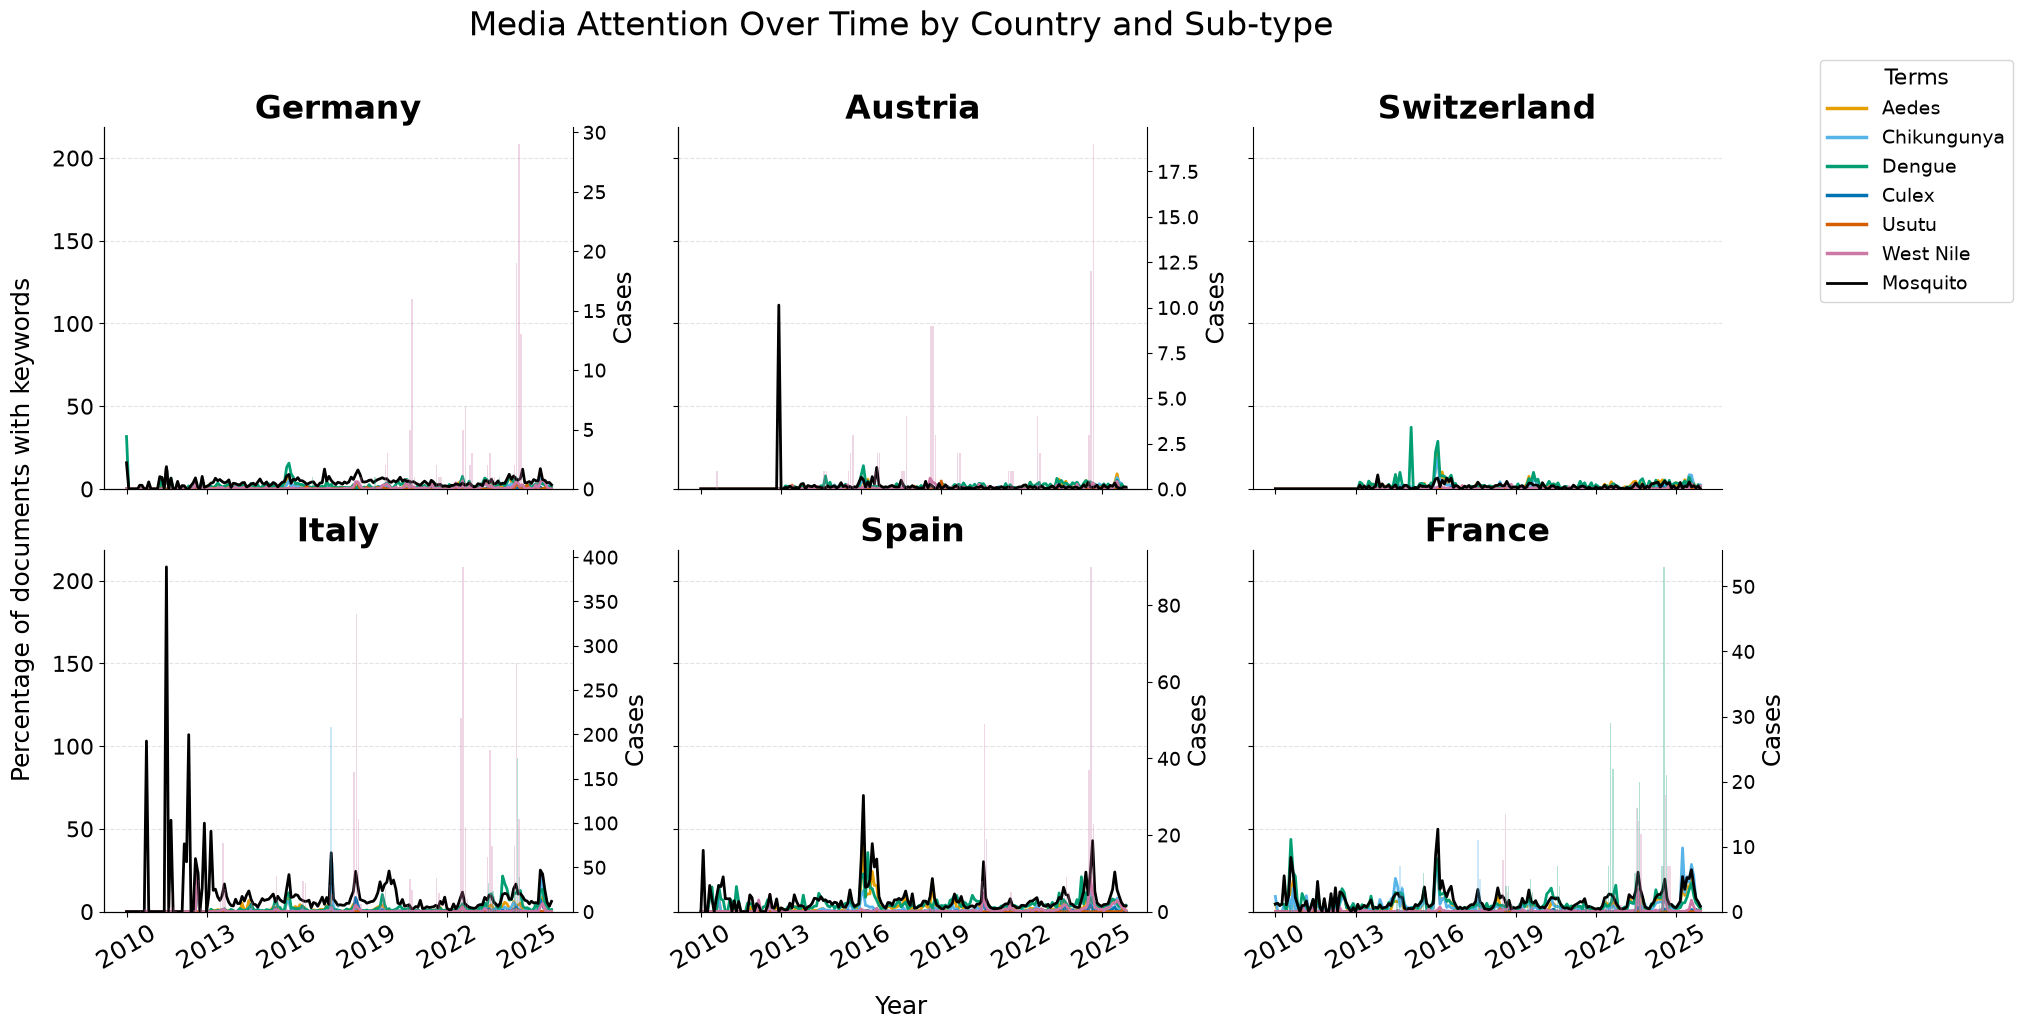

In [43]:
# Subtypes
subtype_df = subtype_df.copy()
subtype_df.index = pd.to_datetime(subtype_df.index, errors="coerce")

countries = [c for c in COUNTRY_ORDER if c in {col[0] for col in subtype_df.columns}]

subtype_to_system = {
    row["Sub-type"]: row["System"]
    for _, row in df[["Sub-type", "System"]].drop_duplicates().iterrows()
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes_flat = axes.flatten()

ratio_cols = [
    col for col in subtype_df.columns
    if col[2] == "ratio"
]

for ax, country in zip(axes_flat, countries):

    # ------------------------------------------------------------------
    # CASE DATA OVERLAY (NEW POSITION: early structured block like reference)
    # ------------------------------------------------------------------
    disease_series = []

    for disease_name, ddf in disease_lookup.items():

        if disease_name == "Zika":
            continue

        country_name = COUNTRY_LABELS.get(country, country)
        dsub = ddf[ddf["country"] == country_name]

        if dsub.empty:
            continue

        dsub = dsub[
            (dsub["date"] >= "2010-01-01") &
            (dsub["date"] <= "2025-01-01")
        ].copy()

        if dsub.empty:
            continue

        dsub["Disease"] = disease_name
        disease_series.append(dsub)

    if disease_series:
        ax2 = ax.twinx()

        offsets = np.linspace(-10, 10, len(disease_series))

        for offset, dsub in zip(offsets, disease_series):

            disease = dsub["Disease"].iloc[0]
            colour = SUBTYPE_COLOURS.get(disease, "grey")

            ax2.bar(
                dsub["date"] + pd.to_timedelta(offset, unit="D"),
                dsub["cases"],
                width=20,  zorder=0, 
                color=matplotlib.colors.to_rgba(colour, alpha=0.3),
            )

        ax2.set_ylabel("Cases", fontsize=18)
        ax2.tick_params(axis="y", labelsize=14)
        ax2.spines["top"].set_visible(False)

    # ------------------------------------------------------------------
    # MAIN SUBTYPE SERIES
    # ------------------------------------------------------------------
    for col in ratio_cols:
        c, subtype, metric = col

        if c != country:
            continue
        if subtype == "Zika":
            continue

        series = subtype_df[col].copy()
        series = series.sort_index()

        colour = SUBTYPE_COLOURS.get(subtype, "#888888")
        system = subtype_to_system.get(subtype, "")

        ax.plot(
            series.index,
            series.values,
            linewidth=2,
            color=colour, zorder=3
        )

    # ------------------------------------------------------------------
    # ANCHOR (unchanged behavior)
    # ------------------------------------------------------------------
    if anchor_df is not None and country in anchor_df.columns.get_level_values(0):

       anc = anchor_df[(country, "ratio")].copy()
       anc = anc.sort_index()

       ax.plot(
           anc.index,
           anc.values,
           color="black",
           linewidth=2,
           linestyle="solid", zorder=4
       )

    # ------------------------------------------------------------------
    # FORMATTING (unchanged)
    # ------------------------------------------------------------------
    ax.set_title(
        COUNTRY_LABELS.get(country, country),
        fontsize=24,
        fontweight="bold",
        pad=6,
    )

    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    ax.tick_params(axis="x", rotation=30, labelsize=18)
    ax.tick_params(axis="y", labelsize=16)

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.xaxis.grid(False)

    ax.spines[["top", "right"]].set_visible(False)

# ----------------------------------------------------------------------
# CLEANUP
# ----------------------------------------------------------------------
for ax in axes_flat[len(countries):]:
    ax.set_visible(False)

fig.text(
    0.005,
    0.5,
    "Percentage of documents with keywords",
    va="center",
    rotation="vertical",
    fontsize=18,
)

fig.supxlabel("Year", fontsize=18)

subtype_handles = [
    mlines.Line2D(
        [],
        [],
        color=colour,
        linewidth=2.5,
        label=subtype,
    )
    for subtype, colour in SUBTYPE_COLOURS.items()
    if subtype in subtype_to_system and subtype != "Zika"
]

anchor_handle = [
    mlines.Line2D(
        [],
        [],
        color="black",
        linewidth=2,
        linestyle="solid",
        label="Mosquito",
    )
]

fig.legend(
    handles=subtype_handles+ anchor_handle,
    title="Terms",
    title_fontsize=16,
    prop={"size": 14},
    loc="upper left",
    bbox_to_anchor=(1.005, 0.98),
    frameon=True,
)

fig.suptitle(
    "Media Attention Over Time by Country and Sub-type",
    fontsize=24,
    y=1.02,
)

plt.tight_layout(rect=[0.02, 0, 1, 1])

for ax in axes_flat[:len(countries)]:
        ax.set_ylim(bottom=0)

fig.savefig(
    OUTPUT_PATH / "Appendix_anchor_no_zika.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## APPENDIX - Monthly

C:\Users\annab\AppData\Local\Temp\ipykernel_48384\1107961553.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])
C:\Users\annab\AppData\Local\Temp\ipykernel_48384\1107961553.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])
C:\Users\annab\AppData\Local\Temp\ipykernel_48384\1107961553.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])
C:\Users\annab\AppData\Local\Temp\ipykernel_48384\1107961553.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0, 0.90, 1])
C:\Users\annab\AppData\Local\Temp\ipykernel_48384\1107961553.py:211: UserWarning: This figure in

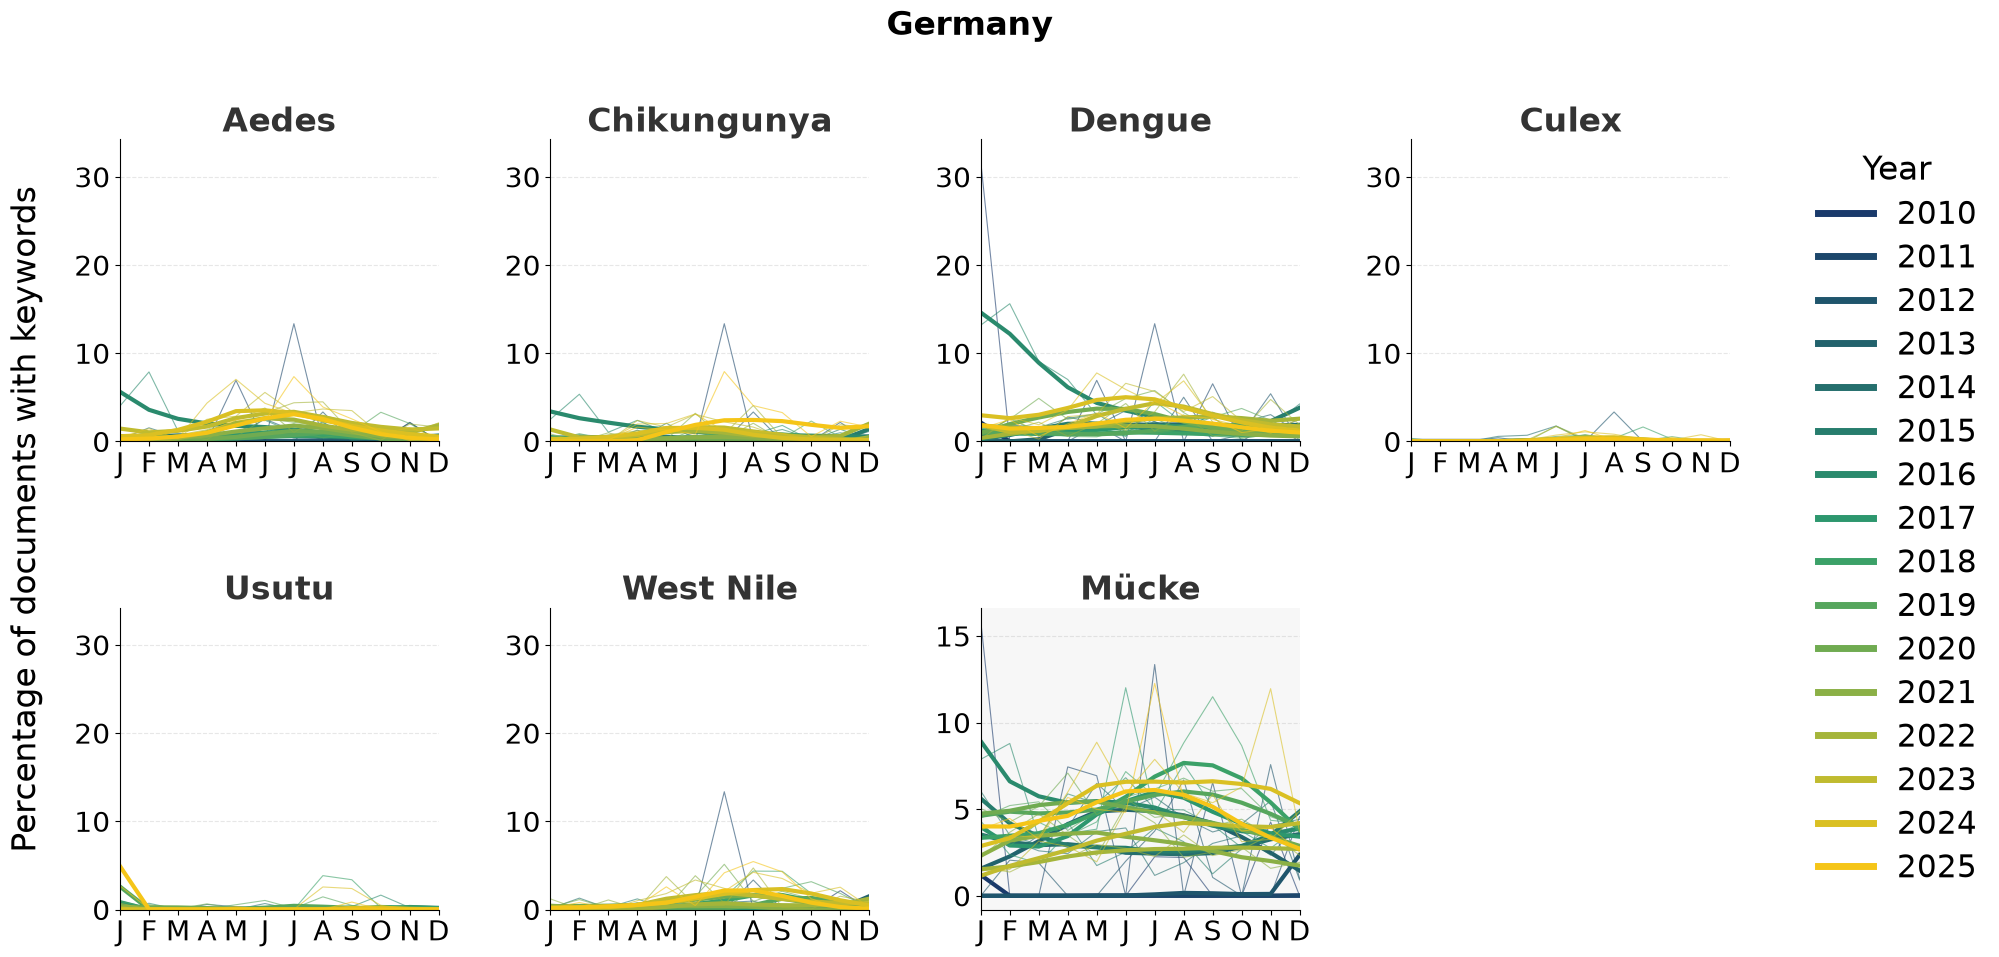

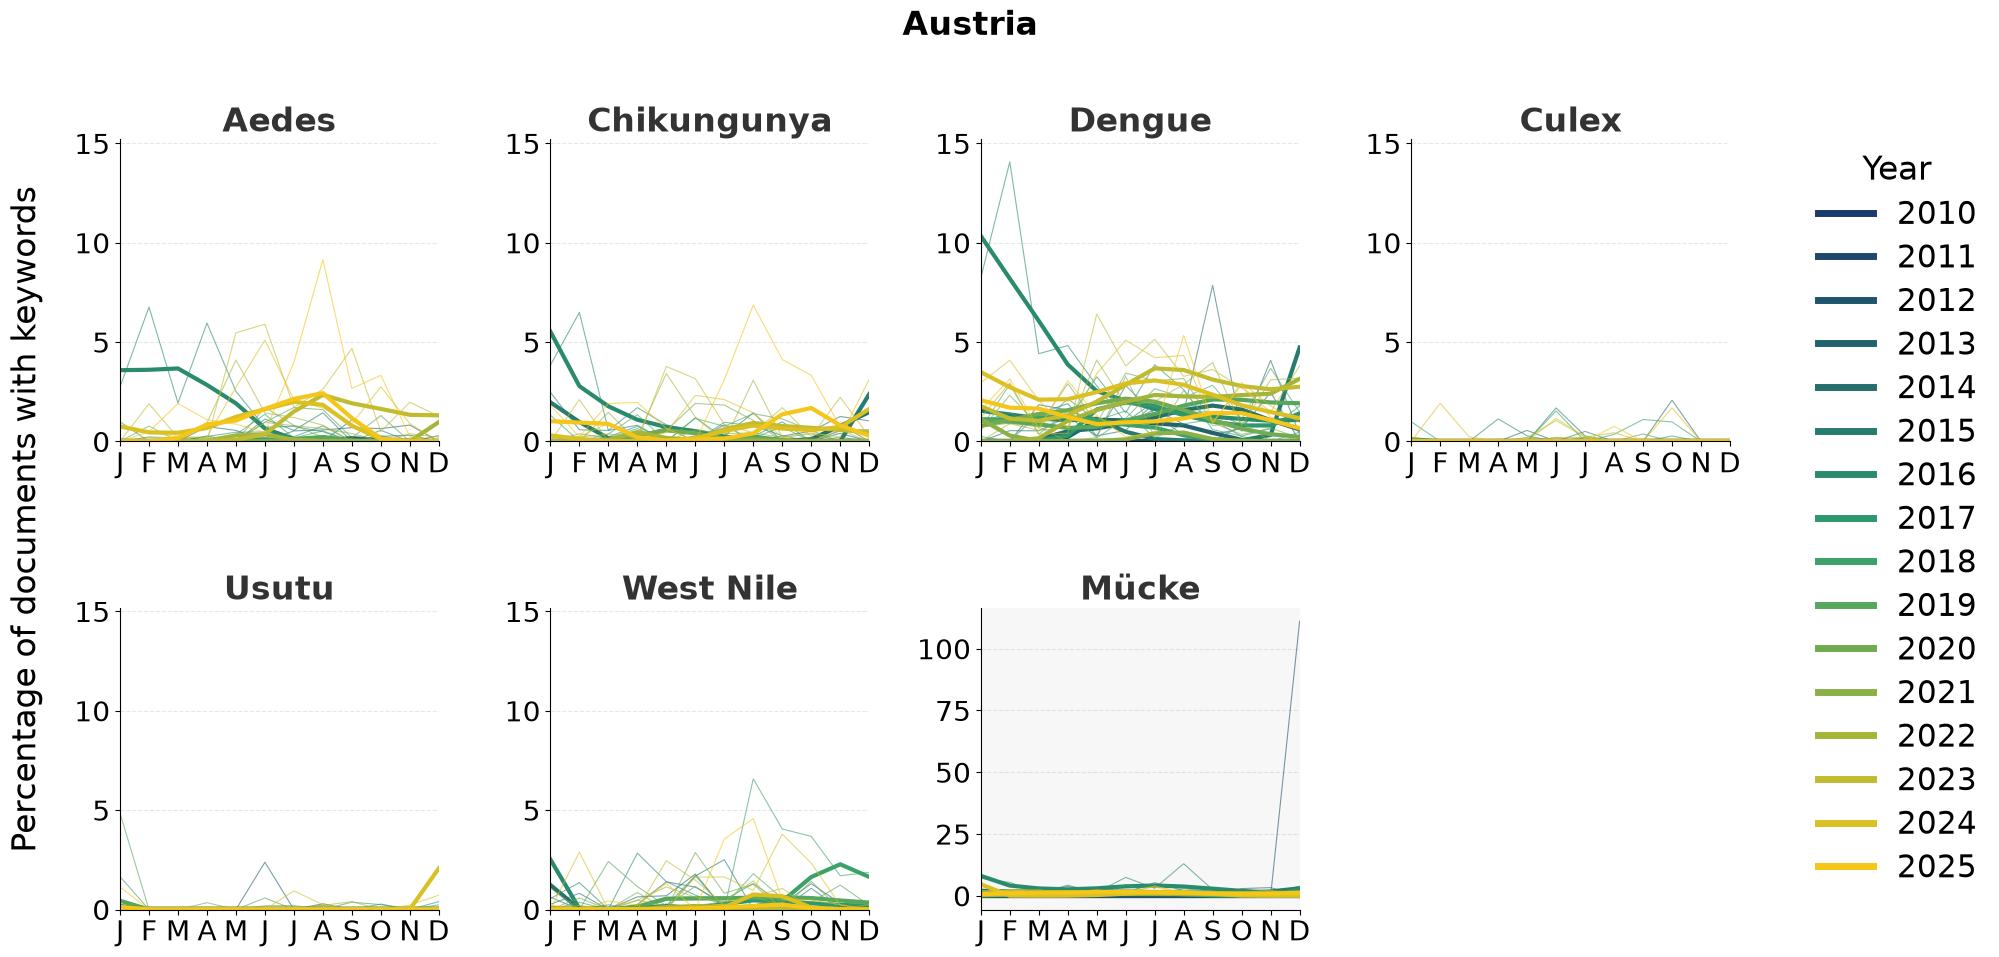

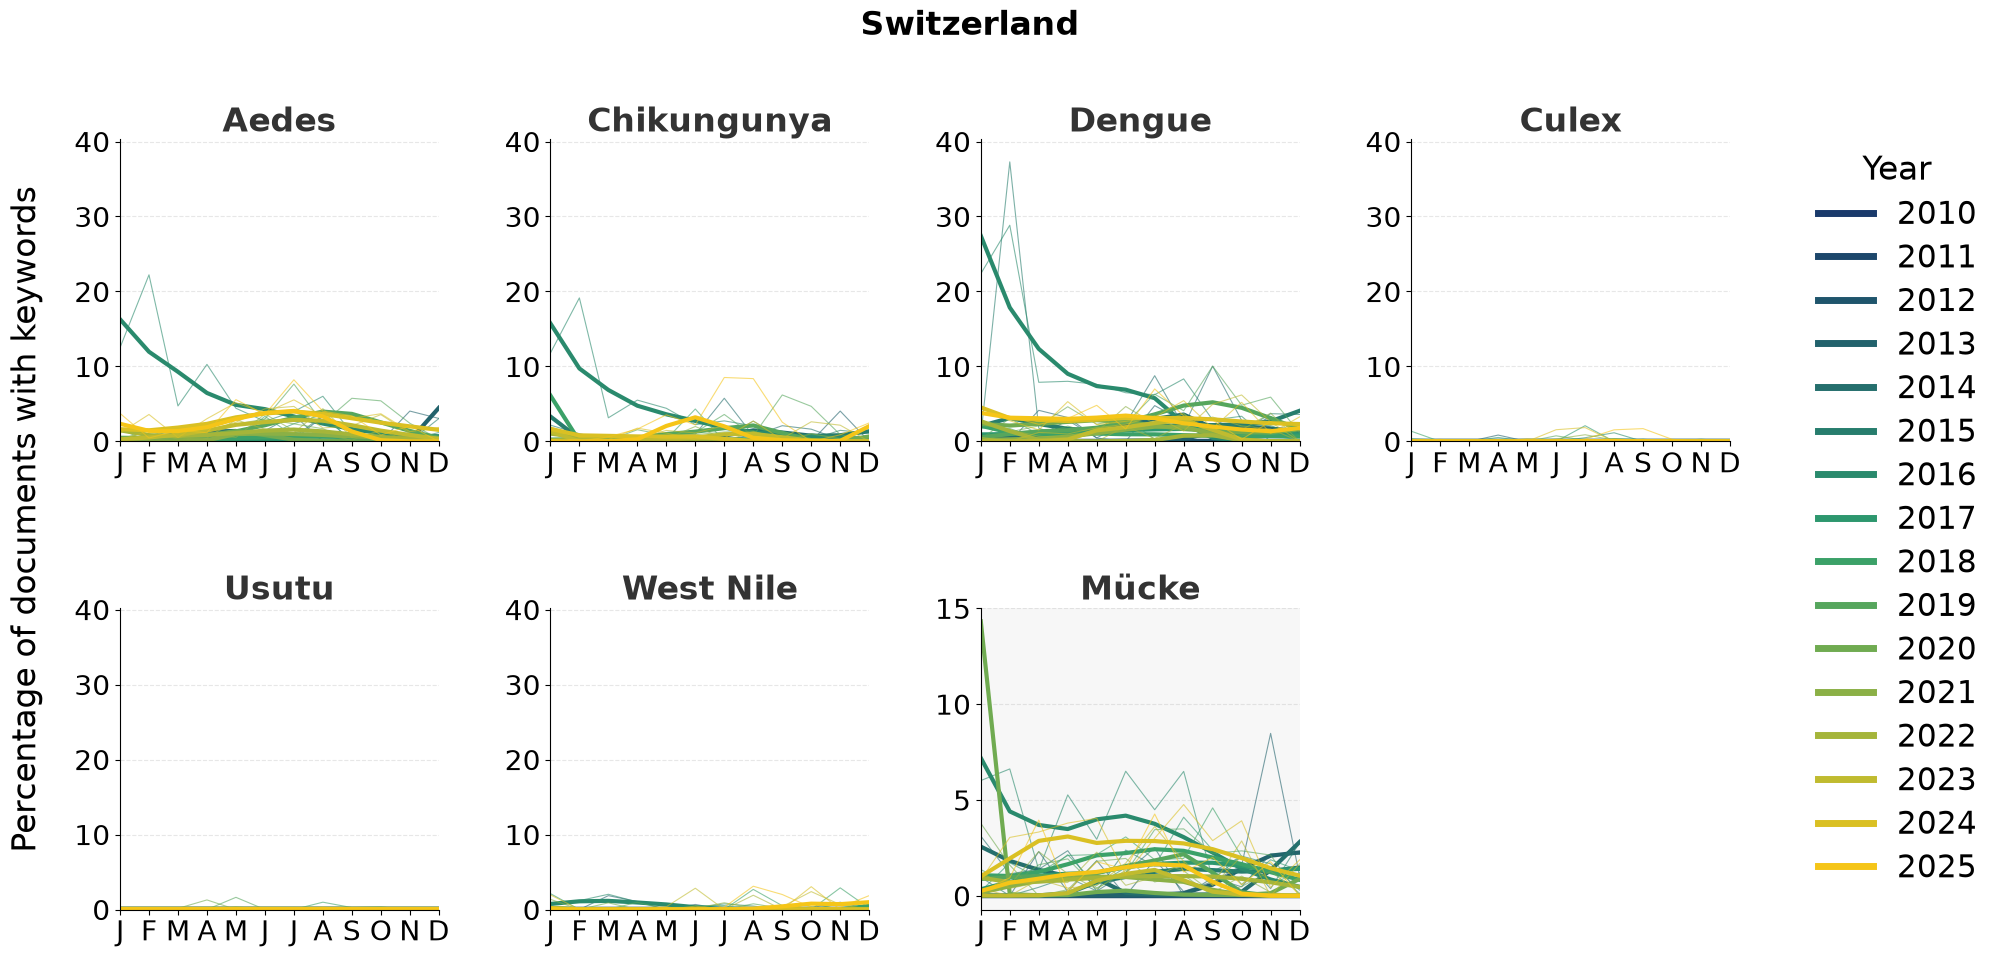

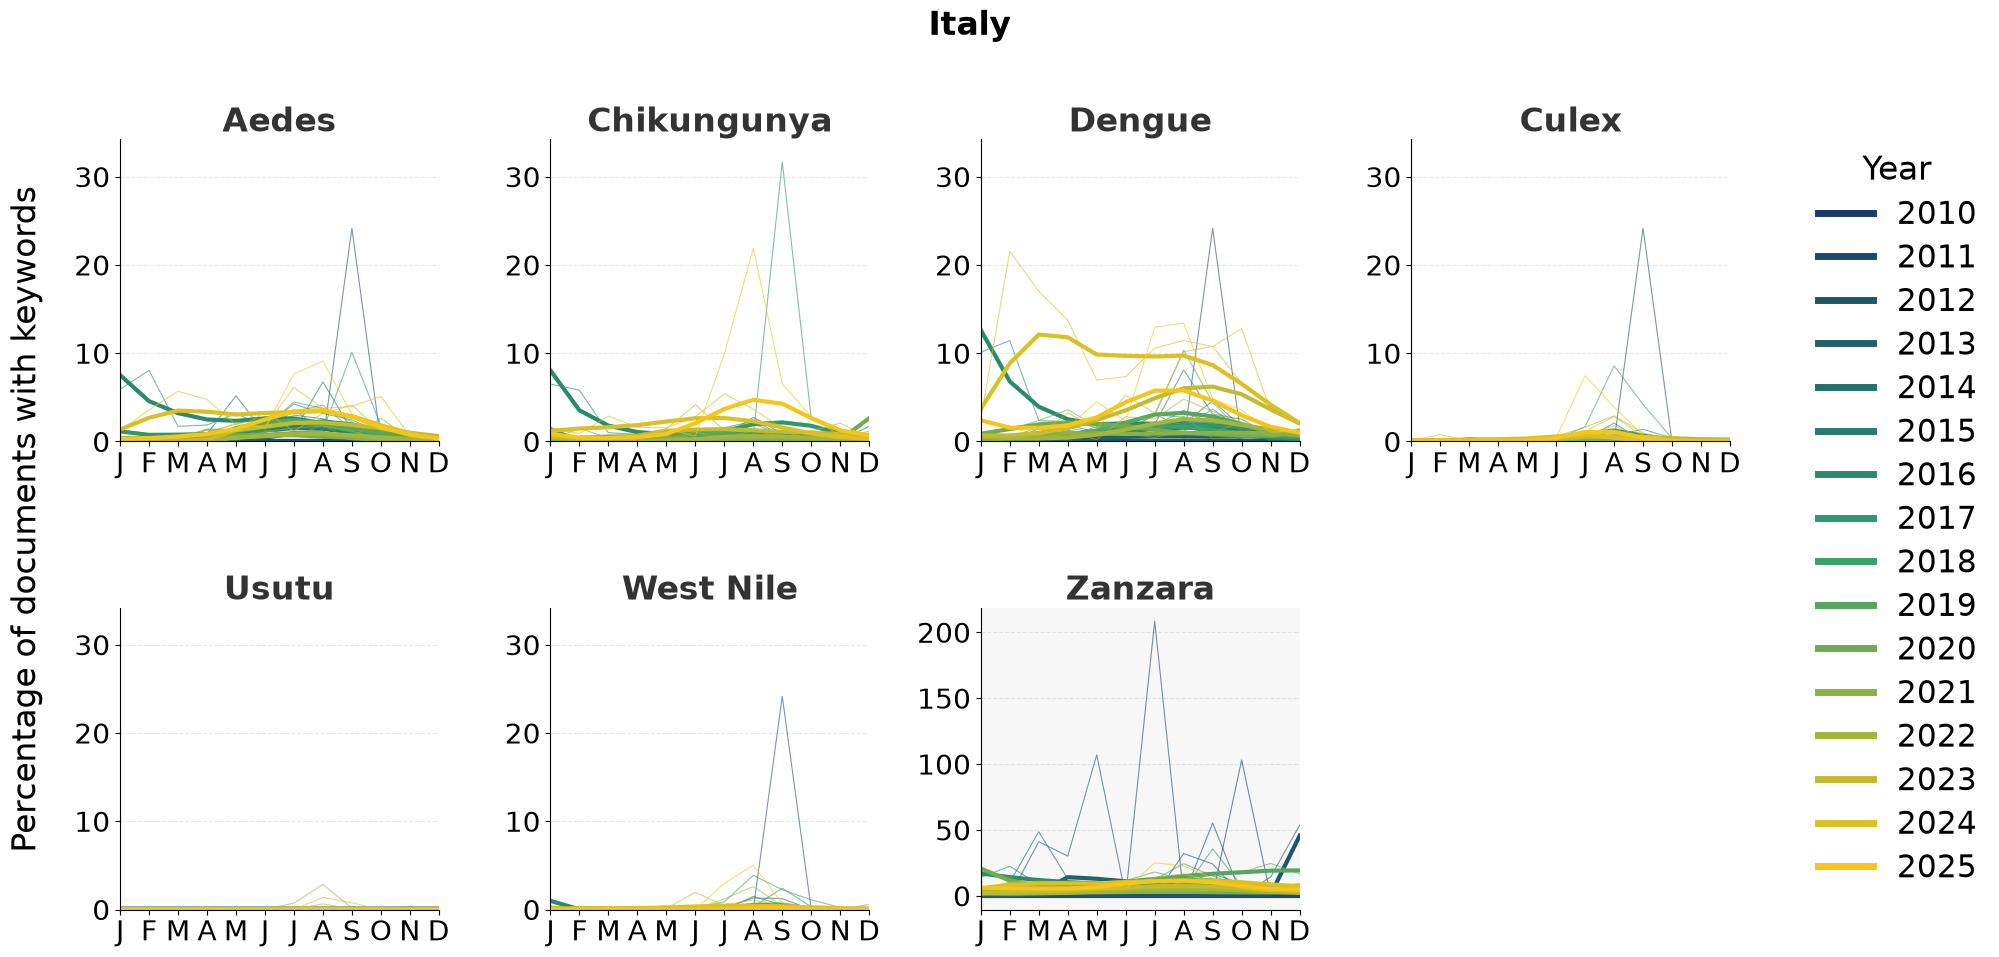

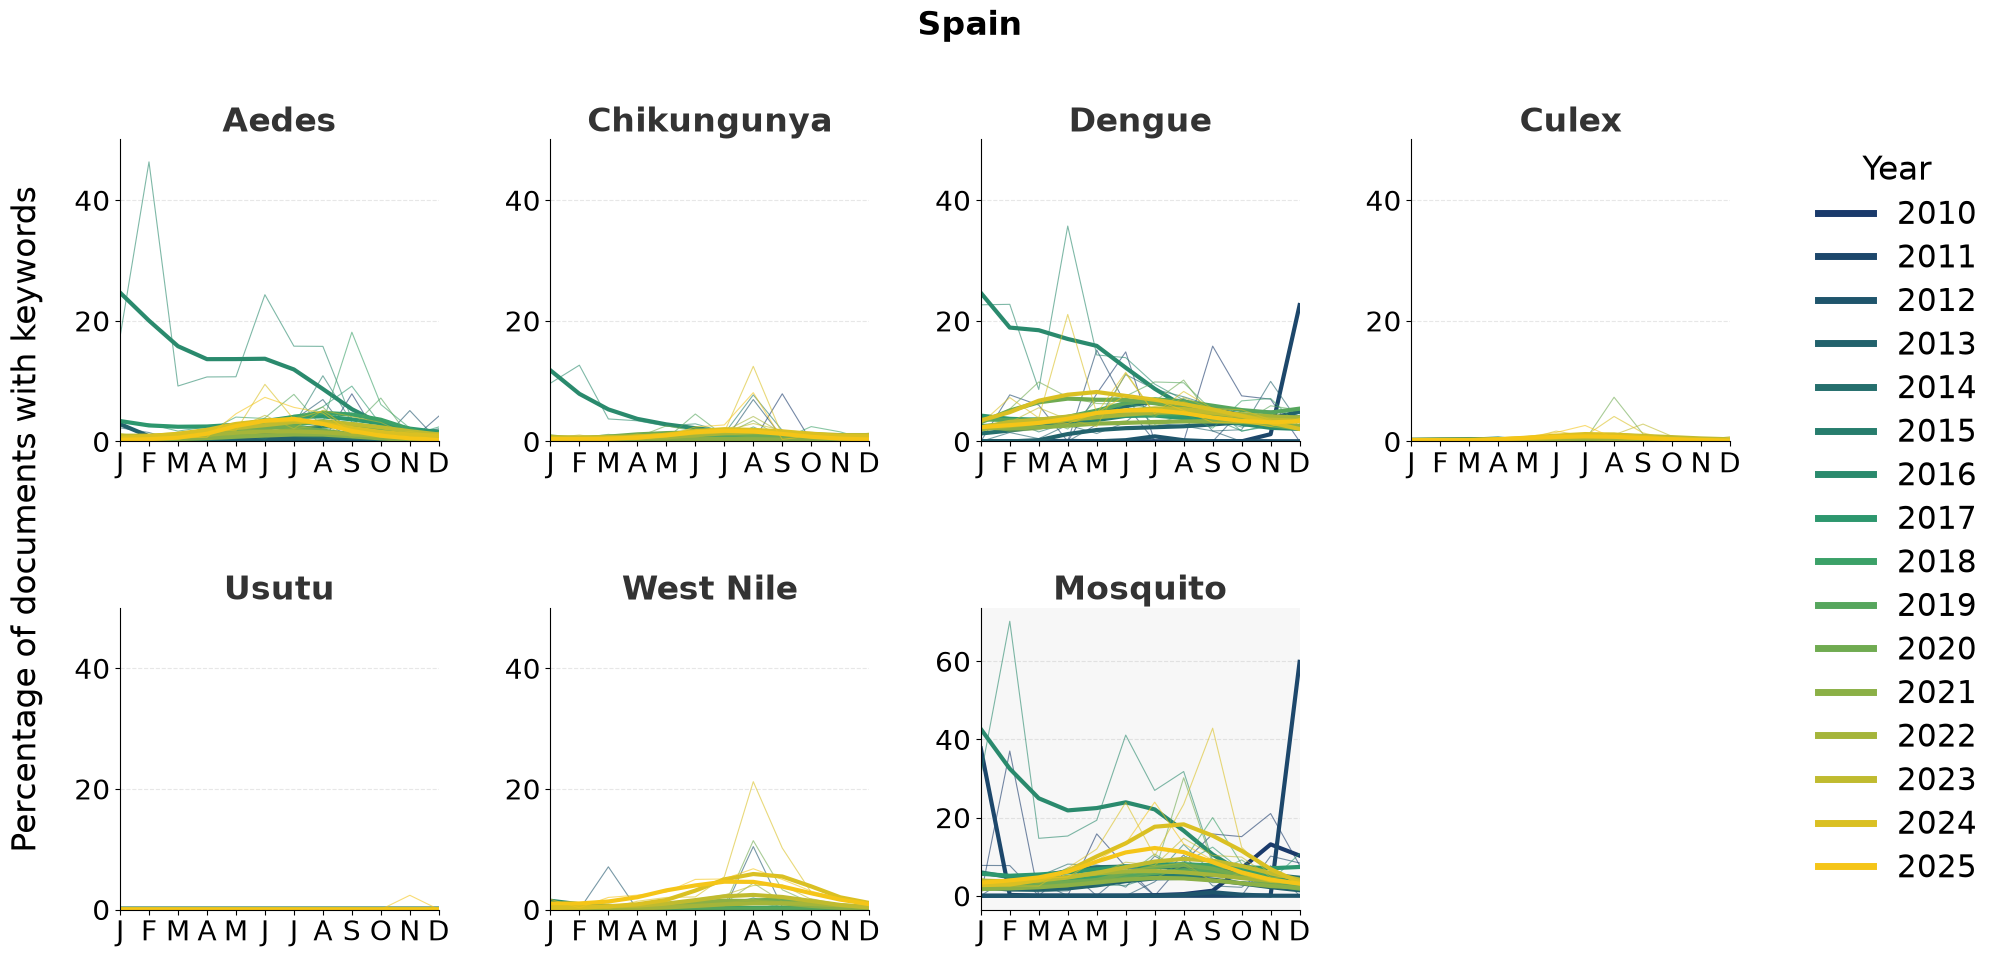

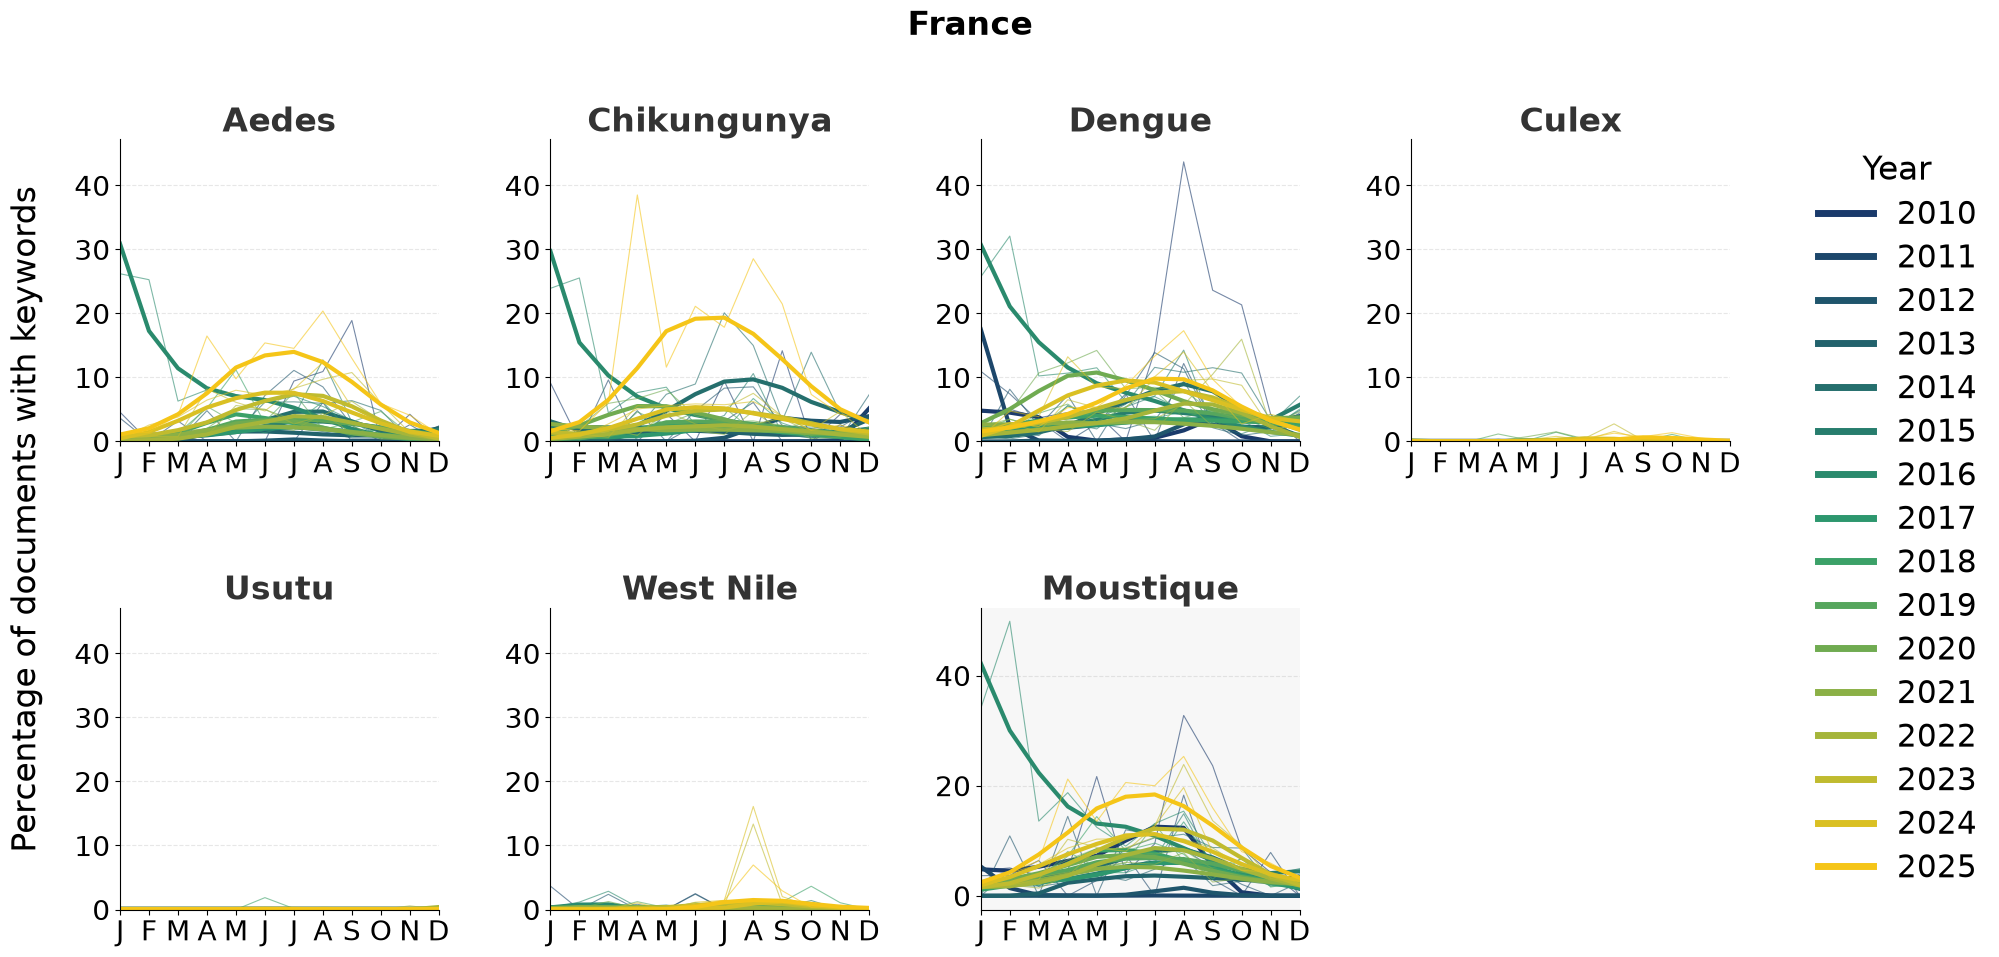

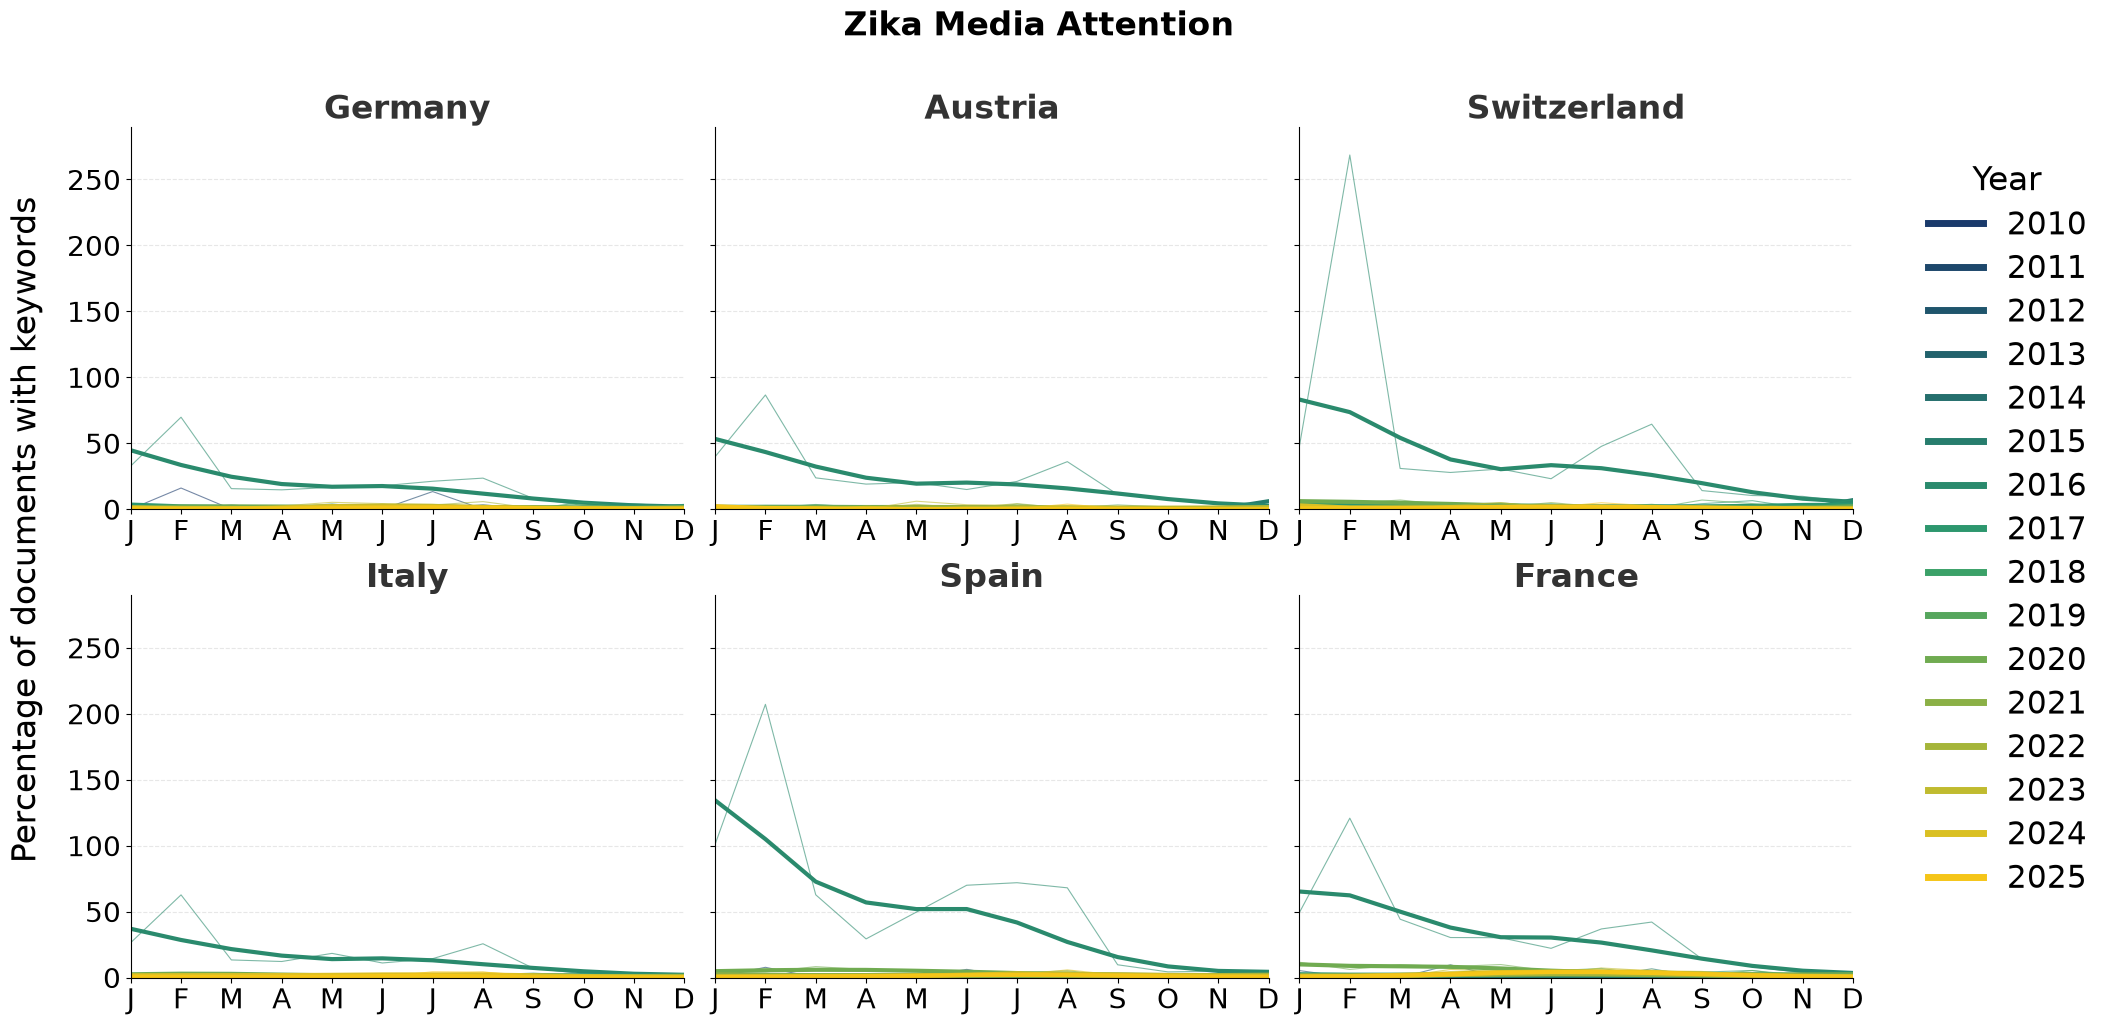

In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# YEAR COLOUR MAP (unchanged structure, cleaned)
# ─────────────────────────────────────────────────────────────────────────────

_GRADIENT_COLOURS = ["#1a3a6b", "#2e9e6e", "#f5c518"]

YEAR_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "blue_green_yellow",
    _GRADIENT_COLOURS,
)


# ─────────────────────────────────────────────────────────────────────────────
# PANEL DRAWER (updated styling + same behaviour)
# ─────────────────────────────────────────────────────────────────────────────

def _draw_series_panel(
    ax,
    series,
    year_colour,
    loess_frac=0.7,
    y_lim=None,
    title="",
    title_colour="#333333",
    facecolor=None,
    month_labels=None,
):

    if month_labels is None:
        month_labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]

    if facecolor:
        ax.set_facecolor(facecolor)

    for yr, yr_series in series.groupby(series.index.year):

        monthly = pd.Series(np.nan, index=range(1, 13), dtype=float)
        monthly.update(yr_series.set_axis(yr_series.index.month))

        x_arr = monthly.index.to_numpy(dtype=float)
        y_arr = monthly.values.astype(float)

        colour = year_colour.get(yr, "grey")

        ax.plot(x_arr, y_arr, color=colour, linewidth=0.8, alpha=0.6)

        smooth = _loess(x_arr, y_arr, frac=loess_frac)
        ax.plot(x_arr, smooth, color=colour, linewidth=3.0, alpha=1)

    ax.set_title(title, fontsize=24, fontweight="bold", color=title_colour, pad=4)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=20, ha="center")

    ax.tick_params(axis="y", labelsize=20)
    ax.set_xlim(1, 12)
    ax.margins(x=0)

    if y_lim:
        ax.set_ylim(*y_lim)

    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)


# ─────────────────────────────────────────────────────────────────────────────
# YEAR LEGEND (unchanged styling update)
# ─────────────────────────────────────────────────────────────────────────────

def _add_year_legend(fig, norm, years_sorted, right_x=0.91):

    handles = [
        mlines.Line2D(
            [],
            [],
            color=YEAR_CMAP(norm(yr)),
            linewidth=5,
            label=str(yr),
        )
        for yr in years_sorted
    ]

    fig.legend(
        handles=handles,
        title="Year",
        title_fontsize=24,
        fontsize=22,
        loc="center left",
        bbox_to_anchor=(right_x, 0.5),
        frameon=False,
        handlelength=1.8,
        handleheight=0.8,
        labelspacing=0.4,
    )


# ─────────────────────────────────────────────────────────────────────────────
# COUNTRY FIGURES (updated grid + dataframe handling like reference code)
# ─────────────────────────────────────────────────────────────────────────────

def plot_timeseries(
    subtype_df,
    anchor_df,
    save_path=None,
    loess_frac=0.7,
    zika_subtype="Zika",
):

    subtype_df = subtype_df.copy()
    subtype_df.index = pd.to_datetime(subtype_df.index)

    # infer structure from MultiIndex columns (kept compatible with your original)
    countries = [
        c for c in COUNTRY_ORDER
        if c in {col[0] for col in subtype_df.columns}
    ]

    subtypes = [s for s in SUBTYPE_COLOURS if s != zika_subtype]

    years_sorted = sorted(subtype_df.index.year.unique())
    norm = mcolors.Normalize(vmin=min(years_sorted), vmax=max(years_sorted))
    year_colour = {yr: YEAR_CMAP(norm(yr)) for yr in years_sorted}

    figures = []

    for country in countries:

        present_subtypes = [
            s for s in subtypes
            if (country, s, "ratio") in subtype_df.columns
        ]

        fig = plt.figure(figsize=(20, 10))

        fig.suptitle(
            COUNTRY_LABELS.get(country, country),
            fontsize=24,
            fontweight="bold",
            y=1.01,
        )

        outer = gridspec.GridSpec(
            2, 4,
            figure=fig,
            hspace=0.55,
            wspace=0.35,
            right=0.88,
            left=0.075,
        )

        non_zika_cols = [
            c for c in subtype_df.columns
            if c[0] == country and c[1] != zika_subtype and c[2] == "ratio"
        ]

        vals = subtype_df[non_zika_cols].values
        y_max = np.nanmax(vals)
        pad = y_max * 0.08 or 1
        y_lim = (0, y_max + pad)

        panels = present_subtypes[:7]

        if (country, "ratio") in anchor_df.columns:
            panels.append("__anchor__")

        panels += [None] * (8 - len(panels))

        for idx, panel in enumerate(panels):

            ax = fig.add_subplot(outer[idx])

            if panel is None:
                ax.set_visible(False)
                continue

            if panel == "__anchor__":

                anc = anchor_df[(country, "ratio")]
                anc.index = pd.to_datetime(anc.index)

                anchor_word = ANCHOR_PER_COUNTRY.get(country, "anchor")

                _draw_series_panel(
                    ax,
                    anc,
                    year_colour,
                    loess_frac=loess_frac,
                    title=f"{anchor_word}",
                    facecolor="#f7f7f7",
                )
                continue

            series = subtype_df[(country, panel, "ratio")]

            _draw_series_panel(
                ax,
                series,
                year_colour,
                loess_frac=loess_frac,
                y_lim=y_lim,
                title=panel,
            )

        fig.supylabel(
            "Percentage of documents with keywords",
            fontsize=24,
        )

        _add_year_legend(fig, norm, years_sorted)

        plt.tight_layout(rect=[0.03, 0, 0.90, 1])

        if save_path:
            out = save_path.parent / f"{save_path.stem}_{country}{save_path.suffix}"
            fig.savefig(out, dpi=150, bbox_inches="tight")

        figures.append(fig)

    return figures


# ─────────────────────────────────────────────────────────────────────────────
# ZIKA FIGURE (updated structure, same labels preserved)
# ─────────────────────────────────────────────────────────────────────────────

def plot_zika_figure(
    subtype_df,
    save_path=None,
    loess_frac=0.7,
    zika_subtype="Zika",
):

    subtype_df = subtype_df.copy()
    subtype_df.index = pd.to_datetime(subtype_df.index)

    countries = [
        c for c in COUNTRY_ORDER
        if (c, zika_subtype, "ratio") in subtype_df.columns
    ]

    years_sorted = sorted(subtype_df.index.year.unique())
    norm = mcolors.Normalize(vmin=min(years_sorted), vmax=max(years_sorted))
    year_colour = {yr: YEAR_CMAP(norm(yr)) for yr in years_sorted}

    n = len(countries)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(7 * ncols, 5 * nrows),
        sharey=True,
        squeeze=False,
    )

    axes = axes.flatten()

    zika_vals = subtype_df[
        [(c, zika_subtype, "ratio") for c in countries]
    ].values
    y_max = np.nanmax(zika_vals)
    y_pad = y_max * 0.08 or 1
    y_lim = (0, y_max + y_pad)

    for ax, country in zip(axes, countries):

        series = subtype_df[(country, zika_subtype, "ratio")]

        _draw_series_panel(
            ax,
            series,
            year_colour,
            loess_frac=loess_frac,
            y_lim=y_lim,
            title=COUNTRY_LABELS.get(country, country),
        )

    for ax in axes[len(countries):]:
        ax.set_visible(False)

    fig.suptitle(
        "Zika Media Attention",
        fontsize=24,
        fontweight="bold",
        y=1.02,
    )

    fig.text(
        0.01,
        0.5,
        "Percentage of documents with keywords",
        rotation="vertical",
        va="center",
        fontsize=24,
    )

    _add_year_legend(fig, norm, years_sorted, right_x=0.91)

    plt.tight_layout(rect=[0.03, 0, 0.90, 1])

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return fig


figs = plot_timeseries(subtype_df,anchor_df,save_path=OUTPUT_PATH / "Mediacloud_subtype_timeseries.png",)

fig_zika = plot_zika_figure(subtype_df,save_path=OUTPUT_PATH / "Mediacloud_zika_by_country.png",)

plt.show()

## NOT USED - Word clouds and bar charts

Load data then plot. Change encoding to encoding=ENCODING when analysis repeated.

In [4]:
system_df2 = pd.read_csv("system_queries_words.csv", encoding="utf-8", header=[0, 1, 2], index_col=0,)
subtype_df2 = pd.read_csv("subtype_queries_words.csv", encoding="utf-8", header=[0, 1, 2], index_col=0,)
anchor_df2 = pd.read_csv("anchor_queries_words.csv", encoding="utf-8", header=[0, 1], index_col=0,)

In [ ]:
# Per subtype
countries = [
    c for c in COUNTRY_ORDER
    if c in {col[0] for col in subtype_df2.columns}
]

for country in countries:
    subtypes = subtype_df2[country].columns.get_level_values(0).unique().tolist()

    panels = []

    anc_data = anchor_df2[country][["term", "doc_ratio"]].dropna().copy()
    anc_data["doc_ratio"] = anc_data["doc_ratio"].astype(float)
    anc_data = anc_data.sort_values("doc_ratio", ascending=False).head(10)
    panels.append(("Anchor query", anc_data, "black"))

    for subtype in subtypes:
        sub_data = subtype_df2[country][subtype][["term", "doc_ratio"]].dropna().copy()
        sub_data["doc_ratio"] = sub_data["doc_ratio"].astype(float)
        sub_data = sub_data.sort_values("doc_ratio", ascending=False).head(10)
        panels.append((subtype, sub_data, SUBTYPE_COLOURS.get(subtype, "#555555")))

    n_panels = len(panels)
    n_cols = 3
    n_rows = -(-n_panels // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 3.0 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for ax, (label, data, color) in zip(axes_flat, panels):
        data_plot = data.iloc[::-1]
        bars = ax.barh(data_plot["term"], data_plot["doc_ratio"] * 100,
                        color=color, height=0.65, edgecolor="none")
        ax.set_title(label, fontsize=10, fontweight="bold", loc="left", pad=6)
        ax.set_xlabel("% of documents", fontsize=8)
        ax.tick_params(axis="y", labelsize=9)
        ax.tick_params(axis="x", labelsize=8)
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)
        ax.grid(axis="x", color="#e6e6e6", linewidth=0.6, zorder=0)
        ax.set_axisbelow(True)
        max_val = data_plot["doc_ratio"].max() * 100
        for bar, val in zip(bars, data_plot["doc_ratio"] * 100):
            ax.text(bar.get_width() + max_val * 0.015, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", ha="left", fontsize=7.5, color="#444444")

    for ax in axes_flat[len(panels):]:
        ax.axis("off")

    fig.suptitle(
        f"Top 10 words by subtype — {country}\n",
        fontsize=13, fontweight="bold", x=0.02, ha="left"
    )
    fig.tight_layout(rect=[0, 0, 1, 0.92])

    save_path = OUTPUT_PATH / f"top_words_{country.lower().replace(' ', '_')}_subtype.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    fig.savefig(str(save_path), bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  anc_data["doc_ratio"] = anc_data["doc_ratio"].astype(float)
C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:19:

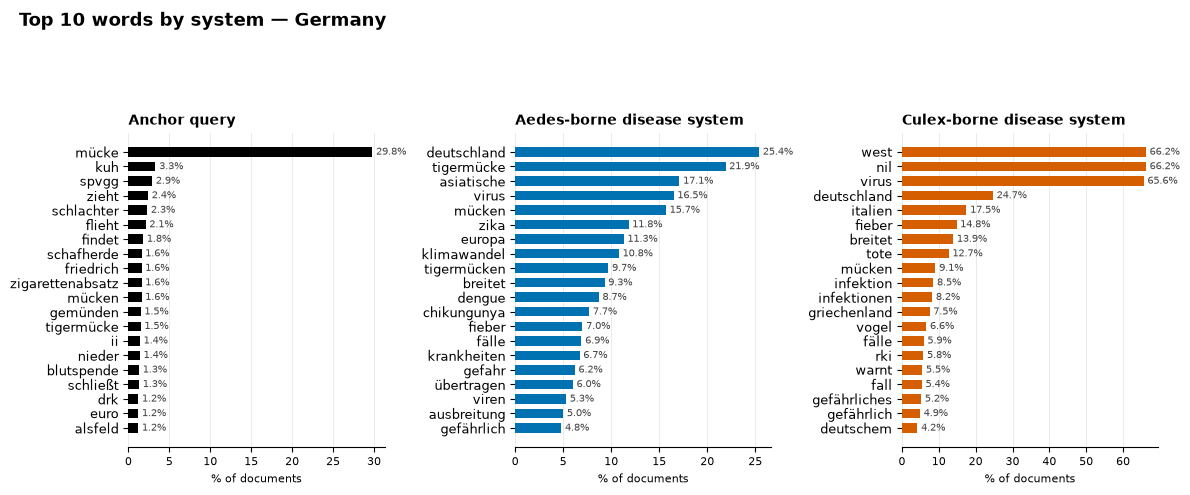

Saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\top_words_germany_system.png


C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  anc_data["doc_ratio"] = anc_data["doc_ratio"].astype(float)
C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:19:

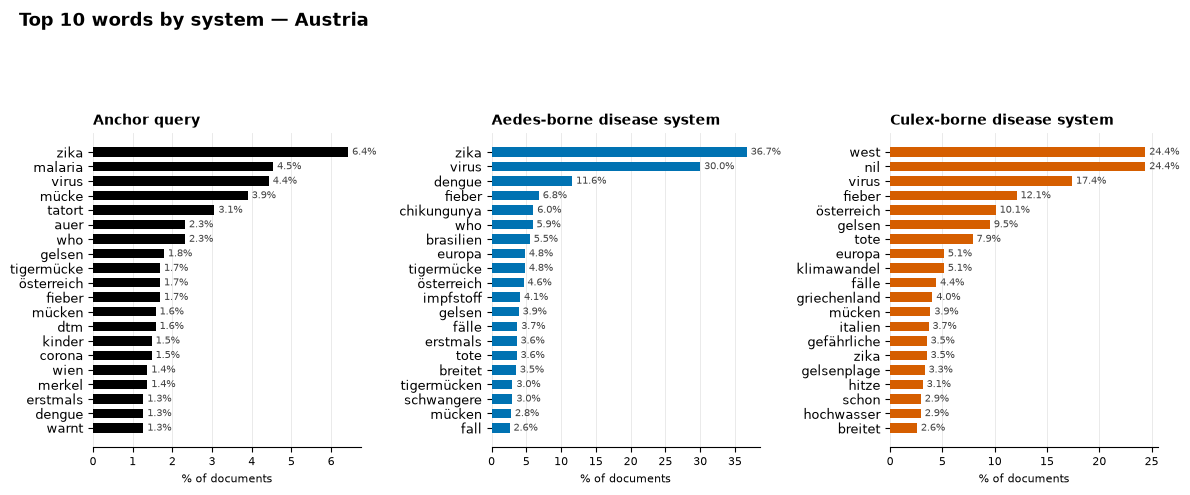

Saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\top_words_austria_system.png


C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  anc_data["doc_ratio"] = anc_data["doc_ratio"].astype(float)
C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:19:

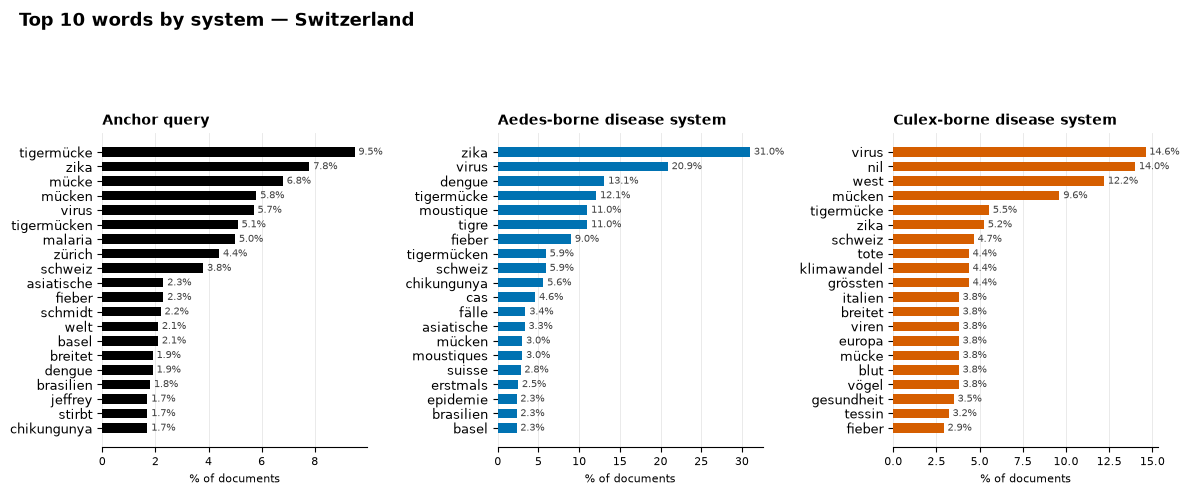

Saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\top_words_switzerland_system.png


C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  anc_data["doc_ratio"] = anc_data["doc_ratio"].astype(float)
C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:19:

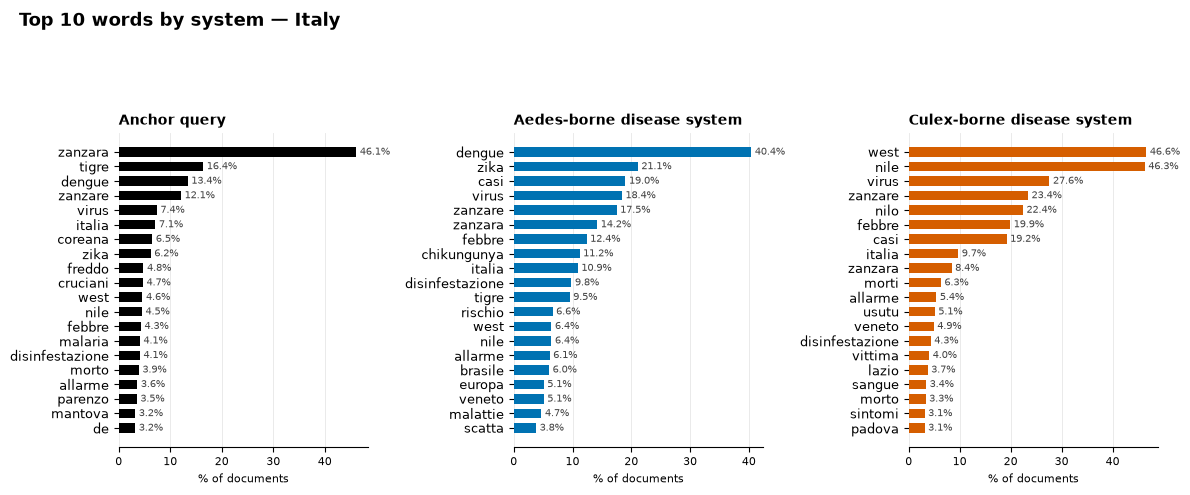

Saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\top_words_italy_system.png


C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  anc_data["doc_ratio"] = anc_data["doc_ratio"].astype(float)
C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:19:

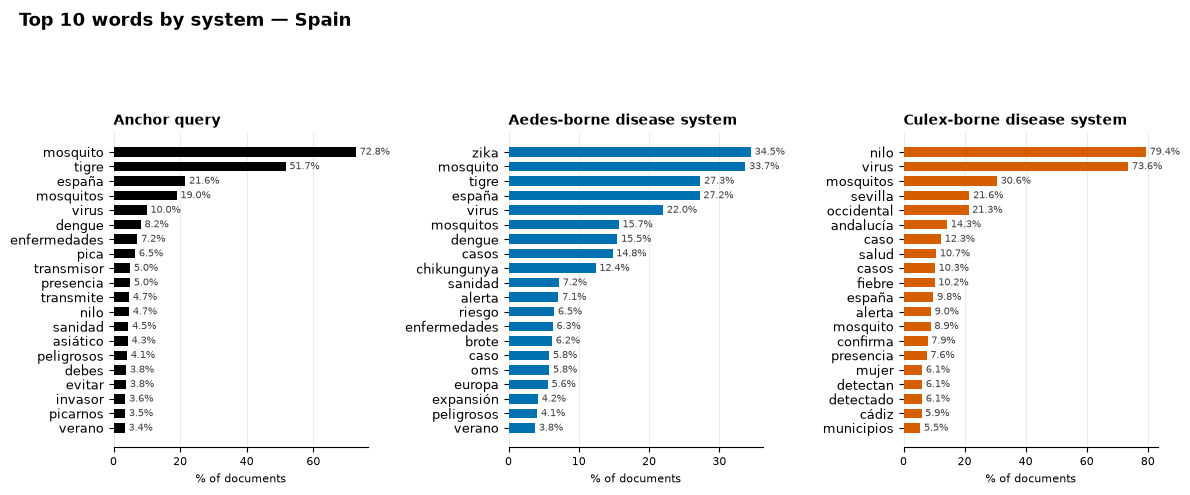

Saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\top_words_spain_system.png


C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  anc_data["doc_ratio"] = anc_data["doc_ratio"].astype(float)
C:\Users\annab\AppData\Local\Temp\ipykernel_32824\1990228783.py:19:

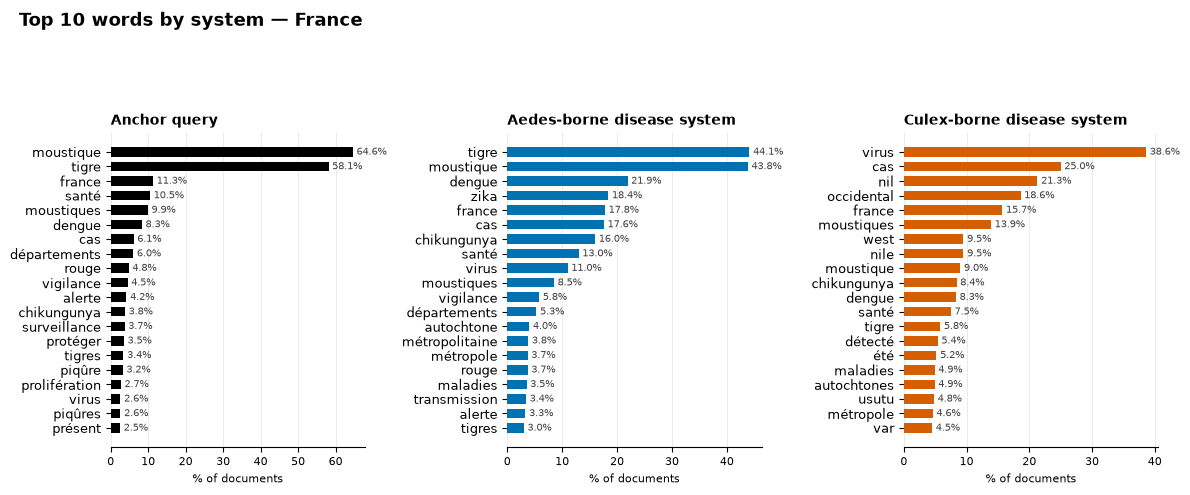

Saved → C:\Users\annab\Documents\Work\2026_Senckenberg_Freelance\One_Health_Proposal_Eugenia\Mediacloud\top_words_france_system.png


In [10]:
# Per system
countries = [
    c for c in COUNTRY_ORDER
    if c in {col[0] for col in system_df2.columns}
]

for country in countries:
    systems = system_df2[country].columns.get_level_values(0).unique().tolist()

    panels = []

    anc_data = anchor_df2[country][["term", "doc_ratio"]].dropna().copy()
    anc_data["doc_ratio"] = anc_data["doc_ratio"].astype(float)
    anc_data = anc_data.sort_values("doc_ratio", ascending=False).head(20)
    panels.append(("Anchor query", anc_data, "black"))

    for system in systems:
        sys_data = system_df2[country][system][["term", "doc_ratio"]].dropna().copy()
        sys_data["doc_ratio"] = sys_data["doc_ratio"].astype(float)
        sys_data = sys_data.sort_values("doc_ratio", ascending=False).head(20)
        panels.append((system, sys_data, SYSTEM_COLOURS.get(system, "#555555")))

    n_panels = len(panels)
    n_cols = 3
    n_rows = -(-n_panels // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 5.0 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for ax, (label, data, color) in zip(axes_flat, panels):
        data_plot = data.iloc[::-1]
        bars = ax.barh(data_plot["term"], data_plot["doc_ratio"] * 100,
                        color=color, height=0.65, edgecolor="none")
        ax.set_title(label, fontsize=10, fontweight="bold", loc="left", pad=6)
        ax.set_xlabel("% of documents", fontsize=8)
        ax.tick_params(axis="y", labelsize=9)
        ax.tick_params(axis="x", labelsize=8)
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)
        ax.grid(axis="x", color="#e6e6e6", linewidth=0.6, zorder=0)
        ax.set_axisbelow(True)
        max_val = data_plot["doc_ratio"].max() * 100
        for bar, val in zip(bars, data_plot["doc_ratio"] * 100):
            ax.text(bar.get_width() + max_val * 0.015, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", ha="left", fontsize=7.5, color="#444444")

    for ax in axes_flat[len(panels):]:
        ax.axis("off")

    fig.suptitle(
        f"Top 10 words by system — {country}\n",
        fontsize=13, fontweight="bold", x=0.02, ha="left"
    )
    fig.tight_layout(rect=[0, 0, 1, 0.92])

    save_path = OUTPUT_PATH / f"top_words_{country.lower().replace(' ', '_')}_system.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    fig.savefig(str(save_path), bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")